# UNO Vision Challenge

## Introduction

blablabla dire que on a une partie classic vision et une partie DL

In [ ]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

PROJECT_DIR = Path.cwd() / "project" if (Path.cwd() / "project").exists() else Path.cwd()
SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import segmentation_utils as seg
from cnn import DEFAULT_MODEL_PATH, Classifier
from notebook_utils import *

BASE_DIR = Path(seg.BASE_DIR)
TEST_DIR = seg.TEST_DIR
TEST_IMAGES_DIR = TEST_DIR
MODEL_PATH = DEFAULT_MODEL_PATH
HISTORY_PATH = SRC_DIR / "symbol_cnn_history.json"

DEMO_IMAGE_PATHS = [
    TEST_DIR / "L1000993.jpg",  # shared segmentation/CNN demo image
    TEST_DIR / "L1000896.jpg",  # white background, grey token
]

demo_images = [Image.open(path).convert("RGB") for path in DEMO_IMAGE_PATHS]
IMAGE_PATH = DEMO_IMAGE_PATHS[0]
img_color = demo_images[0]



# Segmentation

## Input Images

The dataset contains two visual setups. Some images are taken on a colorful table background with a yellow circular active-player token, while others are taken on a white background with a grey rectangular token. The token is important for the final pipeline because it identifies the active player, but it also interferes with color segmentation if it is not handled explicitly.

We display one example of each setup here to verify that the pipeline recognizes both cases. The rest of the notebook then continues with the first image, the same frame used later for the CNN patch demo, so the segmentation and classification examples follow one continuous image.



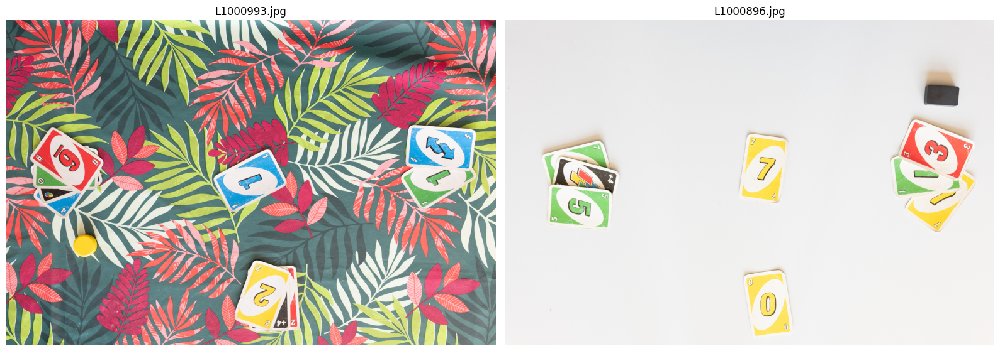

In [3]:
fig, axes = plt.subplots(1, len(demo_images), figsize=(8 * len(demo_images), 6))
axes = np.atleast_1d(axes)

for ax, path, image in zip(axes, DEMO_IMAGE_PATHS, demo_images):
    show_image(image, path.name, ax=ax)

plt.tight_layout()


## Image Type And Token Center

The first decision is which type of active-player token is present. `image_token_type` uses the average image brightness as a simple cue: white-background images are much brighter overall and use the grey token, while colorful-background images are darker overall and use the yellow token.

`get_token_center` then uses a different localization method for each token type. For the yellow token, the pipeline thresholds yellow pixels and looks for a circular component with `find_circle_hough`, because the token is approximately round. For the grey token, the pipeline thresholds the grey HSV range, keeps the largest connected component with `biggest_object`, and returns its centroid with `mask_center`.



L1000993.jpg: detected token type = yellow; token center = (637, 1852)
L1000896.jpg: detected token type = grey; token center = (3570, 622)


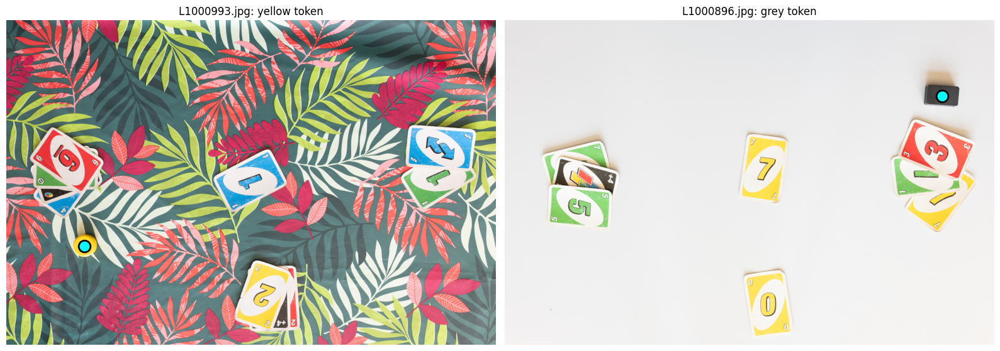

In [4]:
fig, axes = plt.subplots(1, len(demo_images), figsize=(8 * len(demo_images), 6))
axes = np.atleast_1d(axes)

for ax, path, image in zip(axes, DEMO_IMAGE_PATHS, demo_images):
    token = seg.image_token_type(image)
    token_center = seg.get_token_center(image)
    print(f"{path.name}: detected token type = {token}; token center = {token_center}")

    show_image(image, f"{path.name}: {token} token", ax=ax)
    if token_center is not None:
        ax.scatter(*token_center, s=180, c="cyan", edgecolors="black", linewidths=2)

plt.tight_layout()


For the rest of the pipeline demonstration we focus on the first image. The CNN section reuses this same frame, which keeps the intermediate masks, extracted patches, and classified symbols tied to one scene.



## Color Masks

The pipeline starts by separating the image into one binary mask per UNO color: blue, green, red, yellow, black, and white. We decided to do this to exploit the color design of the cards. `get_color_masks` loads the HSV ranges from `hsv_thresholds/`, applies `cv2.inRange` for each configured range, and combines the ranges belonging to the same color. Each of the hsv thresholds defined by the .txt files in the `hsv_thresholds/` were chosen manually on a sample of training images using the `hsv_tuner.py` tool.

HSV is used instead of raw RGB because hue and saturation are more stable under changes in brightness, and allow for easier segmentation of the different colors. After thresholding, each mask is morphologically closed with `morph_close` to fill small gaps, then passed through `min_area_filter` so small components are removed.



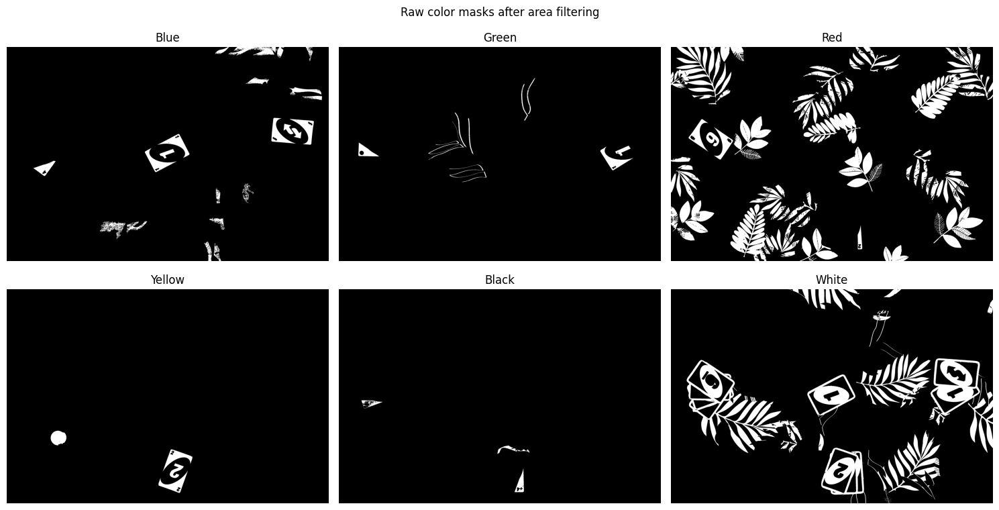

In [5]:
color_masks = seg.get_color_masks(img_color)
show_masks(color_masks, title="Raw color masks after area filtering")


At this point in the pipeline, we can see some card parts as well as a lot of noisy elements, especially from the background. The next steps will focus on refining this segmentation of cards.

## Token Removal

The active-player token can have the same color as objects we care about. On colorful backgrounds the token is yellow, so it may be mistaken for a yellow card region. On white-background images the grey token can overlap with the black mask.

`remove_token_from_color_masks` solves this problem by forcing to 0 pixels from the yellow/black masks, if their coordinates correspond to coordinates of token pixels. 


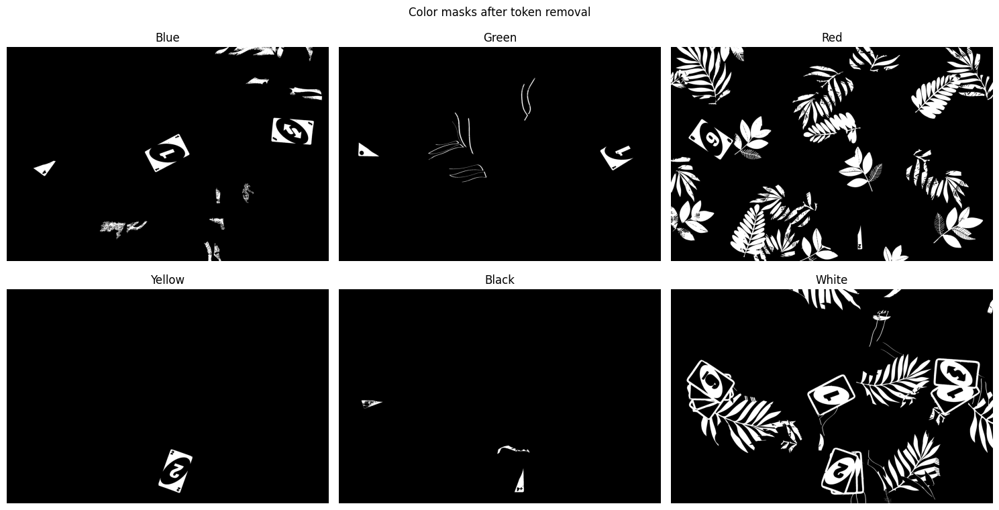

In [6]:
token_removed_masks = seg.remove_token_from_color_masks(
    img_color,
    {color: mask.copy() for color, mask in color_masks.items()},
)
show_masks(token_removed_masks, title="Color masks after token removal")


We can see that the yellow token that previously appeared in the yellow mask has been suppressed and can no longer be mistaken for a card in the rest of the pipeline.

## Keep Card-Like Objects

After color thresholding, a mask may still contain non-card objects: table artifacts, shadows, parts of the token that survived the previous step, or noise that survived the area filter. The UNO cards in these images have a useful structural property: colored card interiors are surrounded by a white border.

`keep_white_surrounded_objects` uses that property to keep only colored components that look card-like. For each object, `keep_objects_surrounded_by_white` builds a ring around the object by dilating it and subtracting the original object. It then measures how much of that ring overlaps the white mask. Components with enough surrounding white are retained; the others are discarded.


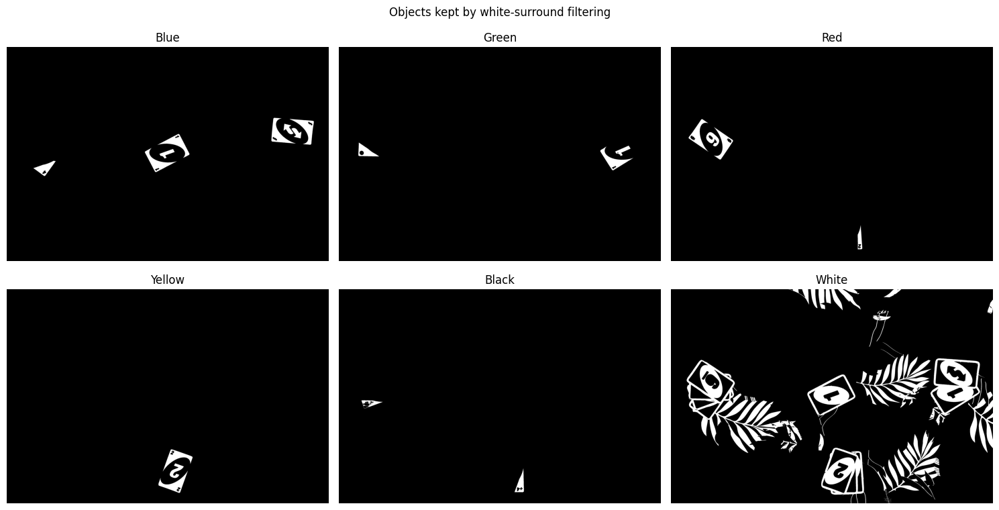

In [7]:
card_masks = seg.keep_white_surrounded_objects(
    {color: mask.copy() for color, mask in token_removed_masks.items()}
)
show_masks(card_masks, title="Objects kept by white-surround filtering")


As we can see, this additional condition for card objects allowed us to remove all the non-card objects from the blue, green, red, yellow, and black masks, which is exactly what we needed for the following steps in the pipeline.

## Holes Inside Card Shapes

Once card-like colored regions are isolated, the next idea is to look for holes inside them. In a binary card mask, white printed symbols appear as missing pixels inside the colored region. `get_holes` fills the exterior background, finds enclosed empty regions, and returns those enclosed regions as candidate symbol pixels.

This step is useful because it turns the symbol search into a shape problem: instead of detecting every possible card symbol directly in RGB space, we first ask which white regions are enclosed by colored cards. The visualization below shows all such enclosed regions before the stricter filtering is applied.



<Axes: title={'center': 'All holes inside colored card regions'}>

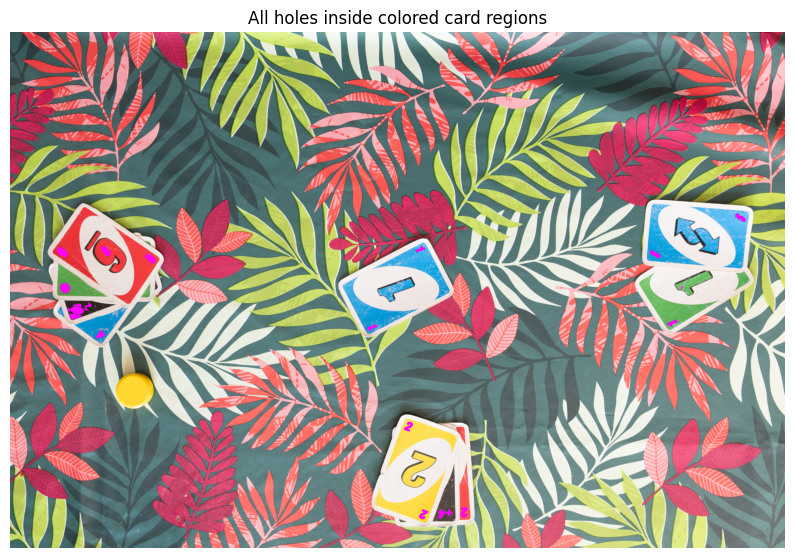

In [8]:
hole_masks = {
    color: seg.get_holes(mask, min_hole_area=100)
    for color, mask in card_masks.items()
    if color != "white"
}
all_holes = np.bitwise_or.reduce(list(hole_masks.values()))
overlay_mask(img_color, all_holes, title="All holes inside colored card regions")


This raw hole-based method is intentionally over-inclusive. Some center symbols contain internal holes themselves, such as `0`, `4`, `6`, `8`, `9`, skip, and `+4`. Those inner holes are not corner symbols, but they are still enclosed by colored pixels, so they appear as candidates.

The next stage filters these candidates using card layout. Corner symbols sit near the white card border, while holes inside the large center symbol remain farther from that border. That spatial difference is what lets us reject many false candidates without needing a classifier yet.



## Filtered Symbol Masks

`extract_symbols_mask_per_color` applies the full symbol-candidate filtering strategy. It starts from the holes found inside each colored card mask, then keeps candidates that are plausible corner symbols.

The key helper is `filter_shapes_by_dilated_ring_overlap_binary`. For each candidate shape, the function dilates the shape and inspects only the newly added ring around it. If that ring overlaps enough white border pixels, the candidate is kept. The dilation radius was selected so that corner symbols are close enough to the card border for their dilation ring to touch white, while false holes inside the central symbol usually stay trapped inside the colored/central-symbol area, even after dilation.

The function also intersects candidates with `white_by_hsv`, a low-saturation mask, to prefer white or near-white symbol pixels and reject colorful artifacts. The result is one cleaned symbol mask per card color.



<Axes: title={'center': 'Final symbol pixels overlaid on the input'}>

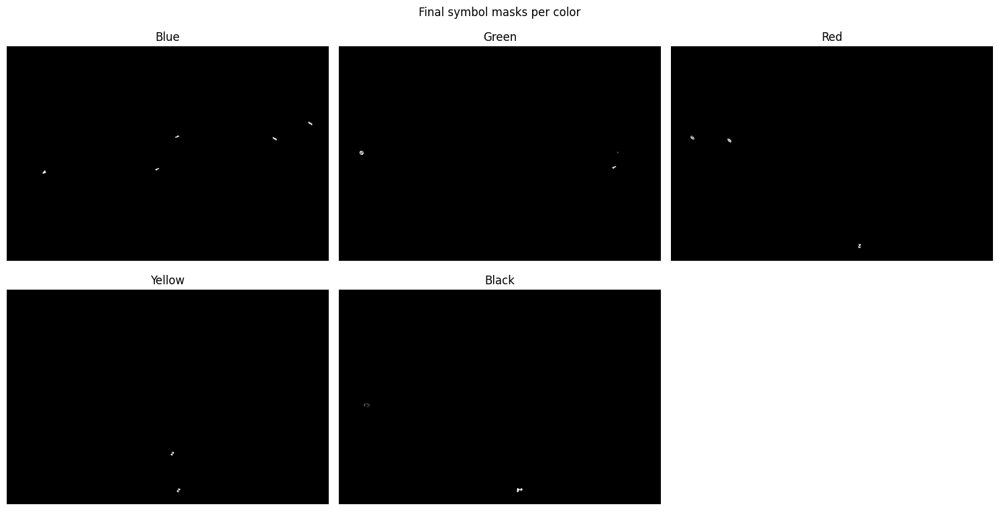

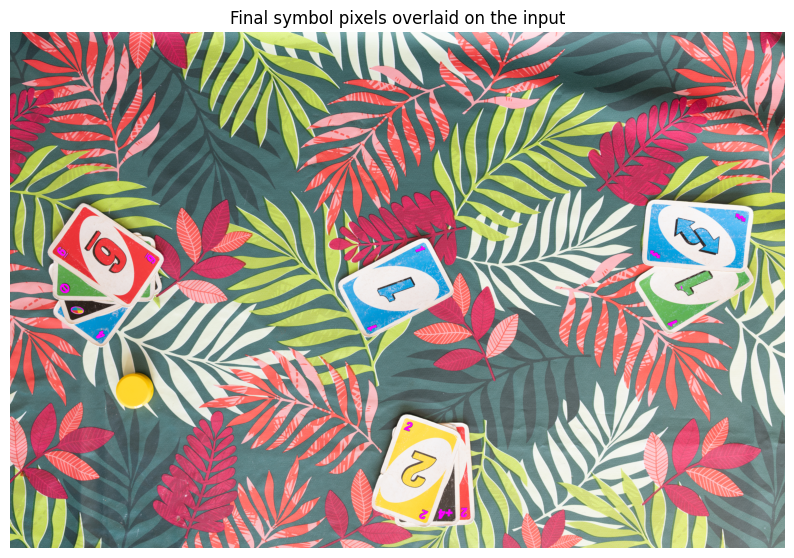

In [9]:
symbols_mask_per_color = seg.extract_symbols_mask_per_color(img_color, card_masks)
total_symbol_mask = np.bitwise_or.reduce(list(symbols_mask_per_color.values()))

show_masks(symbols_mask_per_color, columns=3, title="Final symbol masks per color")
overlay_mask(img_color, total_symbol_mask, title="Final symbol pixels overlaid on the input")


As we can see in the result image, the corner symbols are now perfectly detected while other previous candidates like the holes in the big center 6 and 8 have been ignored.

## Extracted Symbol Patches

The final segmentation output must be usable by the CNN classifier. `detect_symbols` therefore wraps all previous steps and converts the final symbol binary masks into individual records.

Inside it, `extract_merged_symbol_records` merges nearby foreground pixels that belong to the same printed symbol, computes each symbol center in the original image, and calls `crop_centered_binary_mask` to create a fixed-size binary patch around the symbol. We decided to choose 150 pixels by 150 pixels patches so that all symbols can fit, while not wasting too much unused space leading to higher parameters in the CNN. Each returned record contains the patch, the card color, and the image-space center. The classifier later predicts the symbol label from the patch, while the color and center are used to reconstruct the card and assign it to a player or the table.



Detected symbols: 15


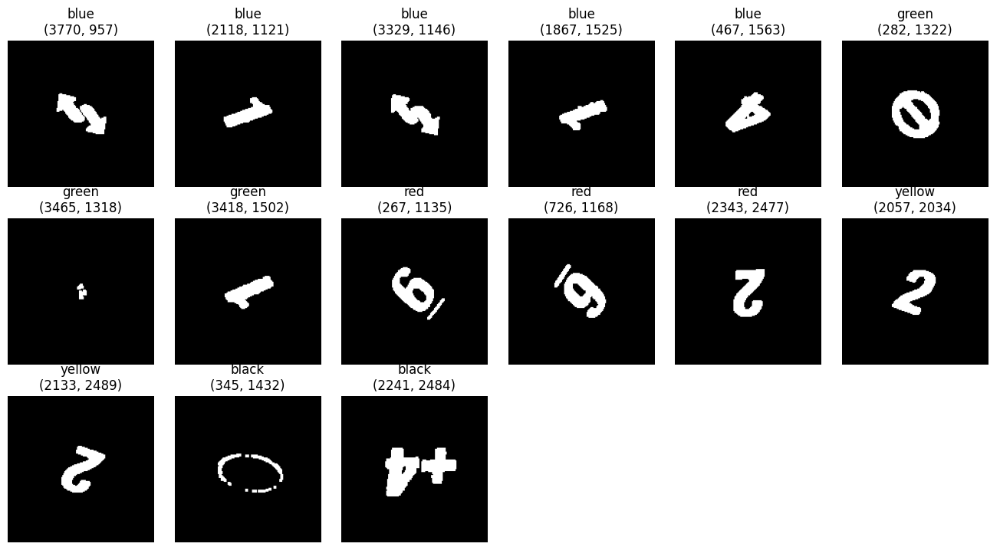

In [10]:
detected_symbols = seg.detect_symbols(img_color)
print(f"Detected symbols: {len(detected_symbols)}")

columns = min(6, max(1, len(detected_symbols)))
rows = int(np.ceil(len(detected_symbols) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(2.2 * columns, 2.4 * rows))
axes = np.atleast_1d(axes).ravel()

for ax, (patch, color, center_xy) in zip(axes, detected_symbols):
    ax.imshow(patch, cmap="gray")
    ax.set_title(f"{color}\n({center_xy[0]:.0f}, {center_xy[1]:.0f})")
    ax.axis("off")

for ax in axes[len(detected_symbols):]:
    ax.axis("off")

plt.tight_layout()


We are now ready to prepare the dataset for classification.

# Data Preparation for Classification

## Symbols Dataset Creation

In order to create the dataset of symbols for the CNN classifier, we created the `build_symbol_dataset` script that runs the segmentation pipeline on all images from the training set explained above and saves all symbol patches into one `symbols_dataset` folder, leading to a dataset of approximately 1100 data points.

## Symbols Dataset Labeling

Once the dataset is created, we need to assign them ground truth labels for the classification step. In order to do this, we created a script `dataset_labeling` that offered us an easy-to-use interactive window for manual labeling of each symbol patch. Labels were then saved in a .json file assigning to each patch name its label. The window can be seen in the image:

<img src="notebook_images/labeling_image.jpg" height="500">

As we can see the annotator had the option to delete samples. This was used on samples where the symbol could not be recognized at all and was likely noise, which is impossible to label accurately.

## Data Augmentation for CNN Classification

### Initial classification approach 

Originally, we tried to implement object description and classification using the classical pipeline introduced in class. Following this approach, we first extracted the main outer contours of the detected UNO symbols and computed Fourier descriptors, as demonstrated in Lab 2 for the MNIST dataset. The goal was to obtain a compact, rotation- and translatio-invariant representation of each symbol based on its boundary geometry.

However, we quickly observed that Fourier descriptors based solely on the outer contour were not sufficient for UNO symbols compared to simpler datasets such as MNIST. The main limitation comes from the structural complexity of UNO symbols. Unlike handwritten digits, several symbols are composed of multiple disconnected components. As a result, restricting the representation to a single outer contour leads to a significant loss of discriminative information.

For example, “+2” and “+4” symbols share the same digit shape as “2” and “4”, meaning that by keeping the main outer contour, the "+" sign is lost and they become undistinguishable. Similarly, the digits “6” and “9” cannot be reliably differentiated from the outer contour alone, since their distinguishing feature lies in a small separate stroke that gets ignored with main outer contour extraction. In addition, symbols such as “0”, “8”, “wild”, and “skip” have very similar outer shapes, which leads to frequent misclassifications when relying only on boundary-based descriptors.

A further difficulty arose from the “wild” class itself, where fragmented and inconsistent images from the dataset often resulted in incomplete or unstable contour extraction. This introduced additional noise into the Fourier representation, further degrading classification performance.

To address these issues, we explored extending the feature set beyond Fourier descriptors. We considered incorporating additional features such as the number of outer contours (to distinguish "+2" from "2" for instance), the card background color (to separate "wild" and "+4" cards), and simple geometric descriptors capturing internal structure. However, this led to an increasingly complex pipeline.

### Choice to move to a CNN-based approach

Given these limitations, we ultimately shifted toward a deep learning-based approach using a Convolutional Neural Network (CNN). Unlike handcrafted descriptors, CNNs learn hierarchical feature representations directly from the extracted binary images. In the early layers, they typically detect simple patterns such as edges, corners, and gradients, while deeper layers combine these into more complex structures such as shapes, digits, and symbol-specific configurations. This allows the network to automatically learn discriminative features for each UNO class, including both global shape information and local details (such as the “+” in “+2” or “+4”), without requiring explicit contour engineering. As a result, CNNs provide a more robust and scalable solution for this classification task compared to manually chosen descriptors.

### Need for the augmentation of the dataset as a consequence

Moving to a CNN-based approach required reviewing the dataset preparation. Unlike classical feature-based methods, CNNs are data-driven and require a sufficiently large and diverse training set to generalize well. Since our original dataset was too small, we used augmentation to artificially increase the variability of the training data.

#### Number of train images in the augmented dataset

We chose to aim for **10 000** training images, which corresponds to roughly **667** images per class for the 15 UNO symbol classes. Below about 500 images per class, the CNN tended to overfit quickly; above about 1 000 images per class, the extra benefit became less clear for these simple binary symbols, and augmentation artefacts started to dominate. Thus, **667** images per class was a reasonable compromise.

#### Train-validation split

We keep a **75/25 stratified split** of the original labeled symbols before augmentation. The training side of this split is then augmented and balanced, while the validation side is deliberately left untouched. This avoids evaluating the CNN on synthetic samples produced by the same augmentation process used for training, and gives a more honest estimate of how the classifier behaves on real extracted symbol patches.

With this policy, the prepared dataset has the following structure:

| Split | Policy | Expected size |
|---|---|---|
| **Train** | Augmented and balanced to ~667/class | **~10 000** |
| **Validation** | Original held-out 25% split, not augmented | **~25% of original symbols** |

#### Augmentation implementation

Augmentation is applied only to the training split. It synthetically expands the data by applying **random rotation (0-360 degrees)** and **small random translations (+/-10 px)** to existing images, then **re-binarizing** to preserve the hard black/white look of the originals. Only the missing training images needed to reach the target are generated; originals are never duplicated or altered.

### 0 — Imports

**Files used by this notebook**
| File | Role |
|---|---|
| `augmentation_utils.py` | All pipeline functions (I/O, splitting, augmentation, …) |
| `notebook_utils.py` | Visualisation helpers (bar plots, count summaries) |

In [11]:
import os
import matplotlib.pyplot as plt
from PIL import Image

from augmentation_utils import *

from notebook_utils import *

### 1 - Configuration

Here we define the input folder `DATA_DIR` containing the original labeled symbol dataset and the output folder `OUT_DIR` for the prepared CNN dataset. `TOTAL_TRAIN` controls how many training images we want after augmentation, while `VAL_RATIO` controls the initial stratified hold-out split.

The validation set is deliberately **not augmented**. It stays composed of original extracted symbols, so it remains a more honest check of generalization than a validation set filled with synthetic variants generated by the same augmentation process as the training set.

In [12]:
DATA_DIR   = PROJECT_DIR / "data" / "symbols_dataset"       # original images + labels.json
OUT_DIR    = PROJECT_DIR / "data" / "augm_symbols_dataset"  # output folder (created if missing)

TOTAL_TRAIN = 10_000   # desired total training images
VAL_RATIO   = 0.25     # fraction of the full dataset kept for validation

### 2 - Load original labels & compute targets

First, we load the dataset labels from `labels.json` and determine how many symbol classes are present.

The training target is computed as:

```python
train_per_class = TOTAL_TRAIN // num_classes
```

Only the training split is balanced by augmentation. The validation split is kept as the original stratified hold-out set, so no validation augmentation target is computed.

In [13]:
labels      = load_json(os.path.join(DATA_DIR, "labels.json"))
num_classes = len(set(labels.values()))

TRAIN_TARGET = compute_train_target(
    num_classes=num_classes,
    total_train=TOTAL_TRAIN,
)

print(f"Classes detected : {num_classes}")
print(f"Original images  : {len(labels)}")
print()
print(f"Train target      : {TRAIN_TARGET:>5} / class  -> {TRAIN_TARGET * num_classes:>6} total")
print("Validation policy : original held-out split only, no augmentation")

Classes detected : 15
Original images  : 1090

Train target      :   666 / class  ->   9990 total
Validation policy : original held-out split only, no augmentation


The original dataset distribution is given by the bar chart of the symbol counts before splitting and augmentation. We can see that the symbols are present in different quantities in the original dataset, meaning they must be split proportionally to create balanced training and validation sets while preserving the original class distribution.

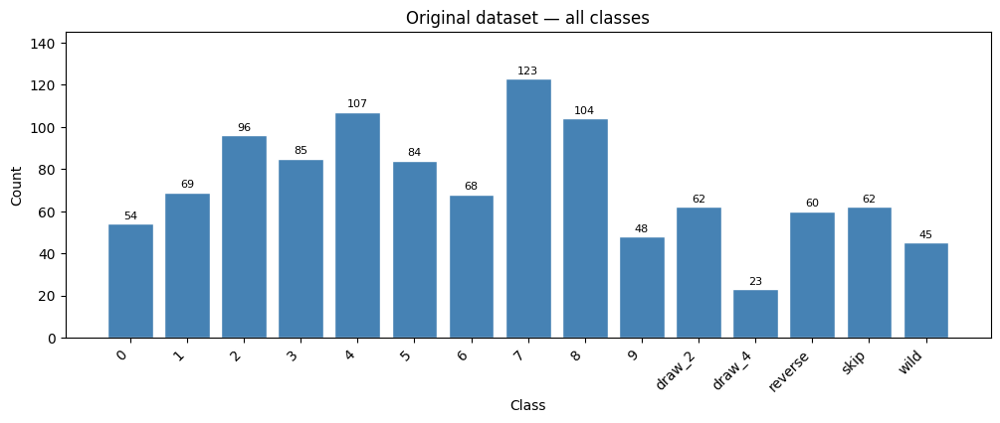

In [14]:
plot_distribution("Original dataset — all classes", labels)
plt.show()

### 3 - Stratified 75/25 train-validation split

Now we split the original dataset into training and validation sets while preserving the class distribution. The function `stratified_split()` groups images by class, shuffles each class with a fixed seed, and assigns `VAL_RATIO` of each class to validation.

The validation split is kept untouched after this point. The training split will be augmented and balanced, but the validation split remains a small held-out set of real extracted symbols.

In [15]:
train_labels, val_labels = stratified_split(labels, val_ratio=VAL_RATIO, seed=42)

print_split_counts(
    train_labels, val_labels,
    TRAIN_TARGET,
    num_classes,
    stage="Before augmentation (originals only)",
)


──────────────────────────────────────────────  Before augmentation (originals only)
  Split          Images  Expected   OK
  ──────────── ────────  ────────  ───
  Train             822      9990    ✗
  Validation        268  held-out    -
  TOTAL            1090     10258
──────────────────────────────────────────────


The dataset distribution of the training and validation sets after splitting is displayed below and shows that the images were separated in the right proportions for each symbols.

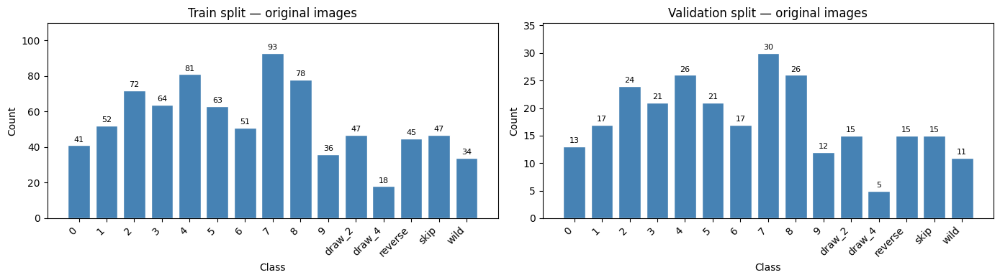

In [16]:
plot_distributions_grid([
    ("Train split — original images", train_labels),
    ("Validation split — original images", val_labels),
])

### 4 — Prepare output folder & copy originals

A safe creation or reuse of an output dataset folder for a stratified image dataset is done with the function `prepare_output_dir()`. It checks whether the output directory already exists and whether it contains both images and the required split files (`train.json` and `val.json`). If the folder is complete, it returns `False`, meaning the pipeline will skip regeneration and simply reload the existing splits from disk. If the folder does not exist, it is created and the function returns `True`, allowing a fresh run. If the folder exists but is incomplete, an error is raised to prevent corrupt or inconsistent datasets from being reused.

If a fresh run is detected, the code saves the initial train/validation splits using `save_json()`, which simply writes Python dictionaries to formatted JSON files. It then copies all original images associated with these splits into the output directory using `copy_images()`, a utility that copies only missing files to avoid duplication. The function `count_files()` is used to count how many image and JSON files exist in both the source and output directories, providing a quick sanity check that the copying step worked correctly. Finally, if the dataset already exists, the script bypasses generation entirely and reloads the saved JSON split files using `load_json()`, ensuring consistency and reproducibility without recomputing or recopying data.

In [17]:
is_fresh_run = prepare_output_dir(OUT_DIR)

if is_fresh_run:
    # Save initial (pre-augmentation) split JSONs
    save_json(train_labels, os.path.join(OUT_DIR, "train.json"))
    save_json(val_labels,   os.path.join(OUT_DIR, "val.json"))

    # Copy original images to output folder
    all_images = list(train_labels.keys()) + list(val_labels.keys())
    copy_images(all_images, src_dir=DATA_DIR, dst_dir=OUT_DIR)

    orig_count, _ = count_files(DATA_DIR)
    out_count,  _ = count_files(OUT_DIR)
    print(f"Original dataset : {orig_count} images")
    print(f"Copied to output : {out_count} images")
else:
    # Folder already complete — reload splits from disk
    train_labels = load_json(os.path.join(OUT_DIR, "train.json"))
    val_labels   = load_json(os.path.join(OUT_DIR, "val.json"))
    print(f"Loaded existing splits — train: {len(train_labels)}, val: {len(val_labels)}")

Copying original images: 100%|██████████| 1090/1090 [00:00<00:00, 1726.53it/s]

Original dataset : 1090 images
Copied to output : 1090 images


### 5 — Augmentation example

Each training image is augmented using the `augment_image()`. This function applies a **random rotation over the full 360° range**, since symbols observed on cards or a table can appear in any orientation during detection. It also applies a **very small random translation (±10 pixels in both directions)** to account for slight misalignments in the dataset, where symbols are intended to be centered but may be slightly shifted due to shadows, noise, or imperfect extraction.

After these geometric transformations, the image is re-binarized to remove interpolation artefacts introduced by bilinear resampling and to preserve the sharp black-and-white structure of the original symbols. The function additionally returns the applied transformation parameters (rotation angle and translations), which allows each augmented sample to be inspected and verified.

In the example shown, one original image is displayed alongside five augmented versions generated from it. Each augmented sample is annotated with its corresponding transformation values (θ, dx, dy).

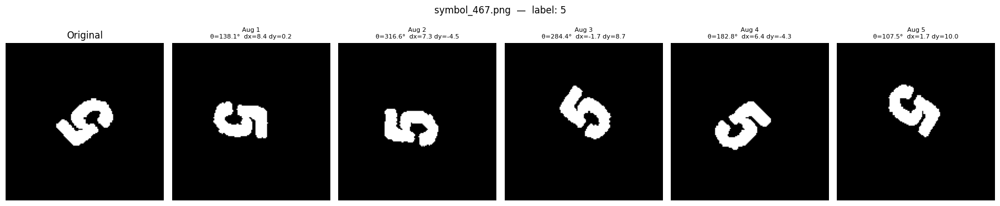

In [18]:
sample_name = list(train_labels.keys())[0]
sample_img  = Image.open(os.path.join(DATA_DIR, sample_name)).convert("RGB")

fig, axes = plt.subplots(1, 6, figsize=(18, 4))

axes[0].imshow(sample_img, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(5):
    aug, angle, tx, ty = augment_image(sample_img)
    axes[i + 1].imshow(aug, cmap="gray")
    axes[i + 1].set_title(f"Aug {i+1}\nθ={angle:.1f}°  dx={tx:.1f} dy={ty:.1f}", fontsize=8)
    axes[i + 1].axis("off")

plt.suptitle(f"{sample_name}  —  label: {train_labels[sample_name]}")
plt.tight_layout()
plt.show()

### 6 - Balance the training split by augmentation

Only the training split is balanced with `complete_split`. For each class, the function counts how many original training images are already present and generates only the missing images needed to reach `TRAIN_TARGET`.

The validation split is not passed through augmentation. It is simply kept as `val_labels` and saved to `val.json`, preserving the original held-out examples for evaluation.

In [19]:
if is_fresh_run:
    start_idx = next_available_index([train_labels, val_labels])

    new_train, _ = complete_split(
        split_labels=train_labels,
        target_count=TRAIN_TARGET,
        src_dir=DATA_DIR,
        out_dir=OUT_DIR,
        start_index=start_idx,
        split_name="TRAIN",
    )
    new_val = val_labels

    # Overwrite JSONs with the final training labels and untouched validation labels
    save_json(new_train, os.path.join(OUT_DIR, "train.json"))
    save_json(new_val,   os.path.join(OUT_DIR, "val.json"))
    print("Saved final train.json and held-out val.json")
else:
    new_train = train_labels
    new_val   = val_labels
    print("Augmentation skipped - output folder already complete.")

Augmenting TRAIN: 100%|██████████| 9168/9168 [00:18<00:00, 498.06it/s]

Saved final train.json and held-out val.json


Finally, we check that the training split reached its augmentation target and that the validation split remained held out. The validation row is marked as `held-out` because it is intentionally not balanced by synthetic augmentation.

In [20]:
print_split_counts(
    new_train, new_val,
    TRAIN_TARGET,
    num_classes,
    stage="After augmentation",
)

total_out, _ = count_files(OUT_DIR)
print(f"\nTotal image files in '{OUT_DIR}': {total_out}")


──────────────────────────────────────────────  After augmentation
  Split          Images  Expected   OK
  ──────────── ────────  ────────  ───
  Train            9990      9990    ✓
  Validation        268  held-out    -
  TOTAL           10258     10258
──────────────────────────────────────────────

Total image files in 'augm_symbols_dataset': 10258


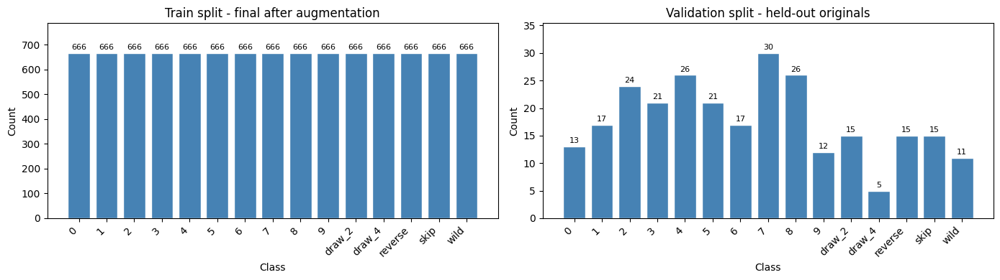

In [21]:
plot_distributions_grid([
    ("Train split - final after augmentation", new_train),
    ("Validation split - held-out originals", new_val),
])

We are now ready to train our classifier.

# CNN Classification

The segmentation section produced fixed-size binary symbol patches and kept their color and image-space position. The next part of the pipeline uses a CNN to assign a symbol label to each patch, then combines this label with the detected color to reconstruct UNO cards.


## CNN Model Loading

The helper `ensure_model` checks whether the trained CNN and its training history already exist. If `symbol_cnn.pt` is present, the notebook reloads the saved weights; if it is missing, `ensure_model` calls `train_with_history` from the CNN module and saves both the model and the training curves.

This avoids retraining the CNN every time the notebook is run, while still making the experiment reproducible from the prepared dataset. The trained model is then loaded through `Classifier`, which wraps the preprocessing and forward pass used later on extracted symbol patches.


## CNN Architecture Choice

The model used for symbol recognition is `SymbolCNN`. Its input is a single-channel `64 x 64` patch produced by `symbol_transform`, because the extracted symbols are binary/greyscale shapes and color is already handled by segmentation. This keeps the classification problem focused on the symbol geometry instead of mixing shape and color information.

The feature extractor uses small `3 x 3` convolutions with increasing channel counts (`32 -> 64 -> 128`). Small kernels are a standard choice for local shape recognition: early layers learn simple edges and strokes, while deeper layers combine them into more complete UNO symbols such as numbers, reverse arrows, skips, and wild-card marks. `BatchNorm2d` stabilizes training, `ReLU` adds non-linearity, and `MaxPool2d` gradually reduces spatial resolution while keeping the strongest local features.

The network is intentionally compact. The dataset contains simple high-contrast symbols, so a very deep architecture would be unnecessary and more likely to overfit augmented artifacts. The `Dropout2d` and final `Dropout` layers add regularization, while `AdaptiveAvgPool2d((1, 1))` replaces a large fully connected head with a global summary of the learned feature maps. The final `Linear(128, num_classes)` layer then maps this compact representation to the symbol classes.


In [22]:
model_path, history_path, history, trained_now = ensure_model(
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    device='auto',
)


if not trained_now:
    print('A model was already trained in a previous run')


A model was already trained in a previous run


## CNN Performance on the Symbol Dataset

Before applying the CNN to a full frame, we evaluate it on the validation split created during data preparation. `evaluate_model` uses `load_model` and `SymbolDataset` from the CNN module to load the saved weights and validation images, then runs the model without shuffling so predictions can be accumulated into a confusion matrix.

The validation split is held out from training, so it gives a first estimate of how well the CNN generalizes to unseen augmented patches. Accuracy measures the global fraction of correct predictions, while the F1 score summarizes precision and recall. `plot_confusion_matrix` then shows the class-by-class behavior, which is useful because two symbols could have a high global accuracy while still being confused with each other.


In [23]:
metrics, confusion_matrix, idx_to_class = evaluate_model(
    model_path=MODEL_PATH,
    dataset_dir=PROJECT_DIR / OUT_DIR,
    labels_file='val.json',
    device='auto',
)
metrics


{'accuracy': 1.0, 'f1': 1.0}

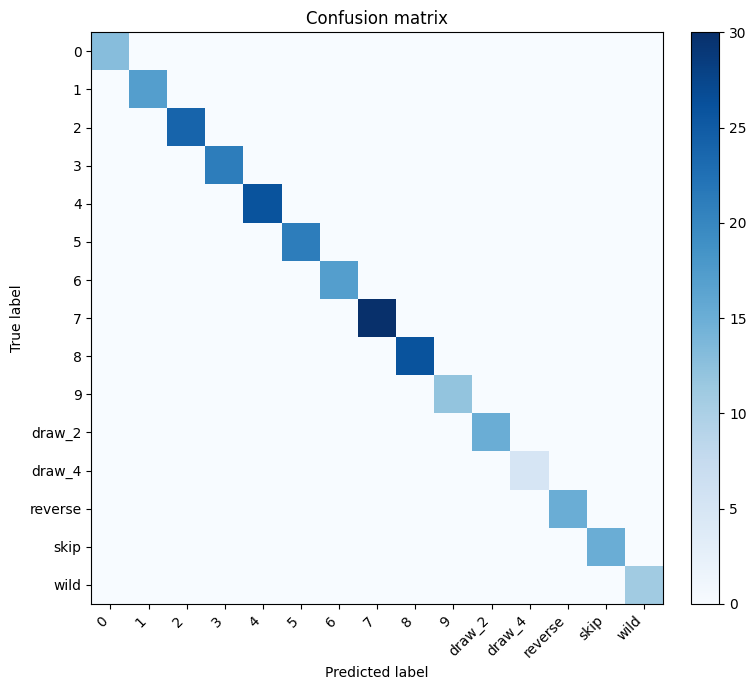

In [24]:
plot_confusion_matrix(confusion_matrix, idx_to_class)
plt.show()


### Performance Analysis

The validation accuracy and F1 score are both equal to `1.0`, which indicates that the CNN correctly classifies every symbol patch in the validation split. 

The confusion matrix supports this result: the predictions lie on the diagonal, meaning that no class is visibly confused with another class. For this dataset, the augmentation strategy seems sufficient to make the model robust to rotation and small shifts in the extracted binary patches.

This result should still be interpreted with the dataset construction in mind. The validation images come from the same symbol-extraction and augmentation process as the training data, so the CNN result mainly validates the symbol classifier once a clean patch has been extracted. In the full image pipeline, errors are more likely to come from segmentation, card grouping, or player attribution than from the CNN itself.


### Training Curves

`plot_history` displays the training and validation accuracy/loss over epochs. The technique here is to compare optimization on the training set with generalization on the validation set: both accuracies should improve, both losses should generally decrease, and the validation curve should not drift away from the training curve.

This gives a visual check for underfitting, overfitting, or unstable training that would not be visible from the final accuracy alone.


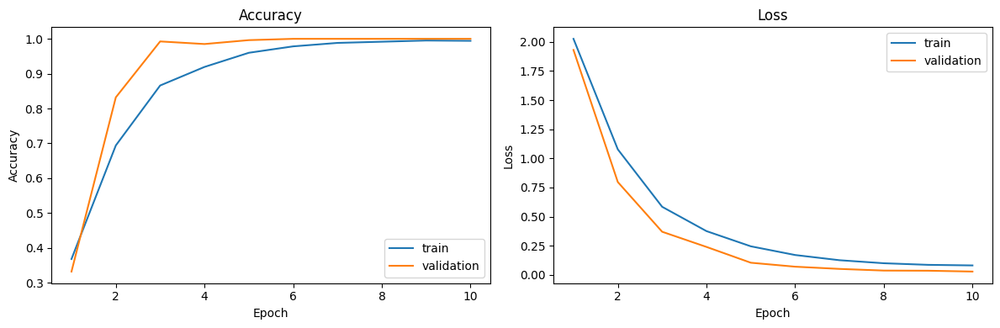

In [25]:
plot_history(history)
plt.show()


### Training Curve Analysis

The curves show that the CNN learns the symbol shapes very quickly. Training accuracy rises from about `0.35` in the first epoch to almost `1.0` by the end, while the training loss decreases steadily across all epochs. This indicates that the model is able to fit the augmented symbol dataset without difficulty.

The validation curve follows the same general trend and reaches `1.0` accuracy from epoch 6 onward. There is one visible instability around epoch 5, where validation loss increases and validation accuracy drops, but the model recovers immediately in the next epoch. Since the validation performance then stays perfect while the loss continues decreasing, this looks like a temporary optimization fluctuation rather than persistent overfitting.

Overall, the training curves are consistent with the final validation metrics: the CNN has converged, and the classification task is well solved once the segmentation pipeline provides clean binary symbol patches.


## CNN Predictions on One Frame

We now apply the classifier to the same frame used in the segmentation section. `Classifier` loads the trained CNN weights, and `show_patch_predictions` calls `build_pipeline_debug`. Inside this call, `detect_and_classify` uses `segmentation.detect_symbols` to extract fixed-size binary patches around the detected corner symbols, then `classifier.classify_patches` applies the CNN to each patch.

The CNN only predicts the symbol shape, not the full UNO card. The full card label is reconstructed afterwards with `card_string`, which combines the segmented card color with the predicted symbol. This separation is useful because color is easier to obtain from classical segmentation, while the CNN focuses on recognizing the symbol shape despite rotation and small translations.

Each displayed patch corresponds to one detected corner symbol. The title shows the reconstructed card label followed by the prediction confidence. At this stage the pipeline has one classified card candidate per detected symbol.


Example frame: L1000993.jpg


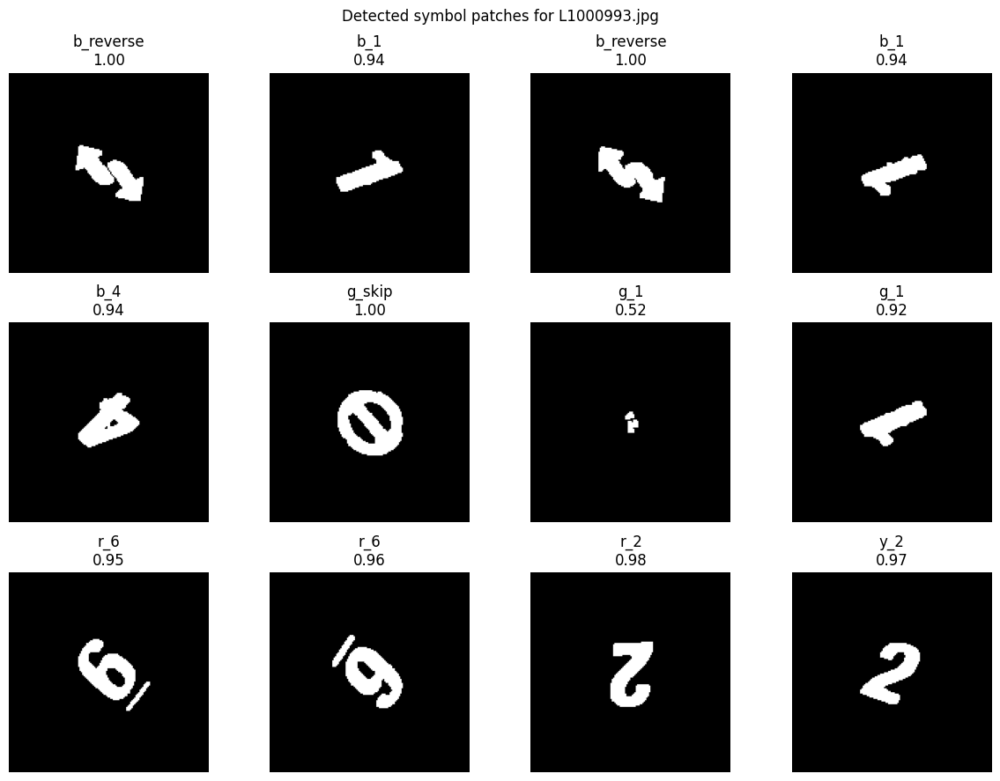

In [26]:
classifier = Classifier(MODEL_PATH, device='auto')
example_frame = IMAGE_PATH
print('Example frame:', example_frame.name)
debug_example = show_patch_predictions(example_frame, classifier)
plt.show()


## Center Card and Player Card Attribution

Once the symbols have been classified, `build_pipeline_debug` calls `assign_players` to attach each detected card to either the center pile or one of the four players. The logic uses geometry: the detections closest to the image center are treated as center-pile candidates, because the played card is expected to be near the middle of the table.

The remaining detections are player-hand candidates. `assign_players` groups their centers with `cluster_points`, then `cluster_2_player_mapping` maps the resulting clusters to the four player anchor regions around the image. The most confident center candidate becomes the central card, while the clustered detections become player cards. `show_pipeline_assignments` visualizes these assignments before duplicate removal, so we can inspect the raw attribution step.


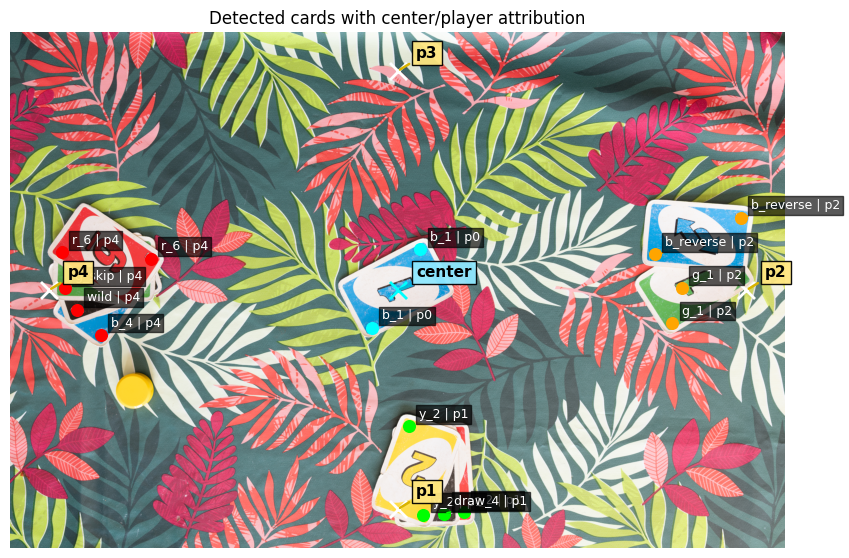

{'image_id': 'L1000993',
 'center_card': 'b_1',
 'active_player': 'p4',
 'player_1_cards': 'y_2;draw_4;r_2',
 'player_2_cards': 'b_reverse;g_1;g_1',
 'player_3_cards': 'EMPTY',
 'player_4_cards': 'r_6;g_skip;wild;b_4'}

In [27]:
show_pipeline_assignments(debug_example, show_image=True, remove_duplicates=False, show_anchors=True)
plt.show()
debug_example['row']


## Token Attribution to the Active Player

The active-player token is detected separately by the segmentation pipeline with `segmentation.get_token_center`. The logic is again geometric: `active_player_from_token` defines four anchor positions around the image, one for each player, and assigns the token to the nearest anchor by Euclidean distance.

`show_token_assignment` displays the token center and the anchor positions so the decision can be inspected visually. This step is independent of the card labels: the CNN identifies what cards are present, while the token position identifies which player is active.


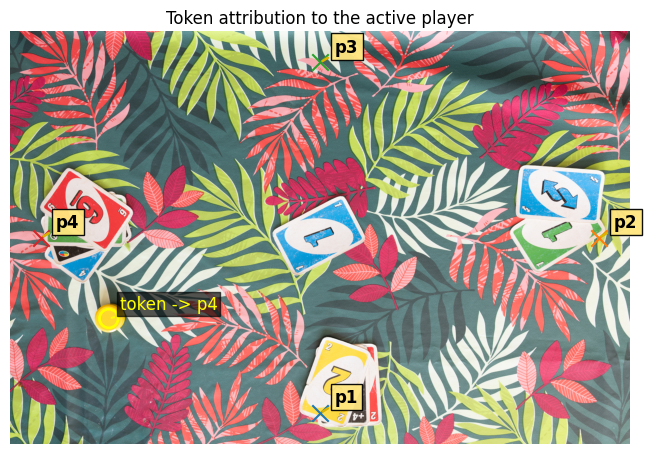

Active player: p4


In [28]:
show_token_assignment(debug_example)
plt.show()
print('Active player:', debug_example['active_player'])

## Duplicate Card Detection Removal

The segmentation can sometimes detect the two printed corner symbols of the same physical card as two separate card detections. This is expected because each UNO card has repeated corner symbols, and both can pass the symbol filter.

After cards have been assigned to players, `sort_player_cards` orders each player's detections in reading order. `collapse_duplicate_detections` then groups detections with the same card label and compares the distance between their centers. If two same-label detections are separated by the expected corner-symbol distance, the second one is removed, because the pair is interpreted as one physical card rather than two identical cards.

The cell below reuses `debug_example`. `show_pipeline_assignments` displays the final player assignments after duplicate removal, and `show_duplicate_collapse` prints the card lists before and after this correction.


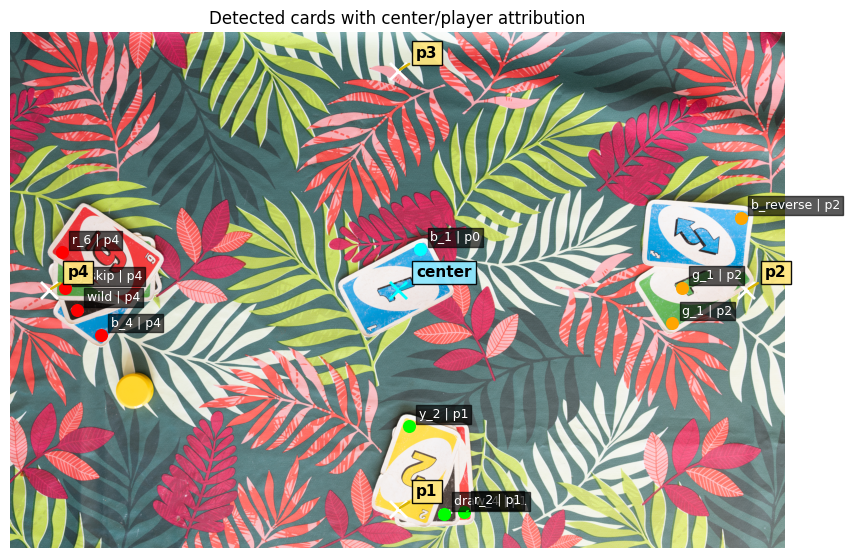

Player 1
  before: ['y_2', 'y_2', 'draw_4', 'r_2']
  after:  ['y_2', 'draw_4', 'r_2']
Player 2
  before: ['b_reverse', 'b_reverse', 'g_1', 'g_1']
  after:  ['b_reverse', 'g_1', 'g_1']
Player 3
  before: ['EMPTY']
  after:  ['EMPTY']
Player 4
  before: ['r_6', 'r_6', 'g_skip', 'wild', 'b_4']
  after:  ['r_6', 'g_skip', 'wild', 'b_4']


In [29]:
show_pipeline_assignments(debug_example, show_image=True, remove_duplicates=True)
plt.show()
show_duplicate_collapse(debug_example)


## Full Pipeline Output

The final cell runs the complete frame pipeline in one call. `build_pipeline_debug` gathers the segmentation output, CNN predictions, center-card assignment, player-card assignment, token attribution, and duplicate removal information. It also calls `prediction_row_for_image`, which converts the intermediate detections into the final submission-style row: one image id, one center card, one active player, and one semicolon-separated card list per player.

`show_full_pipeline_frame` visualizes the result on the original image, while the displayed row shows the exact structured output that can be written to the submission CSV.


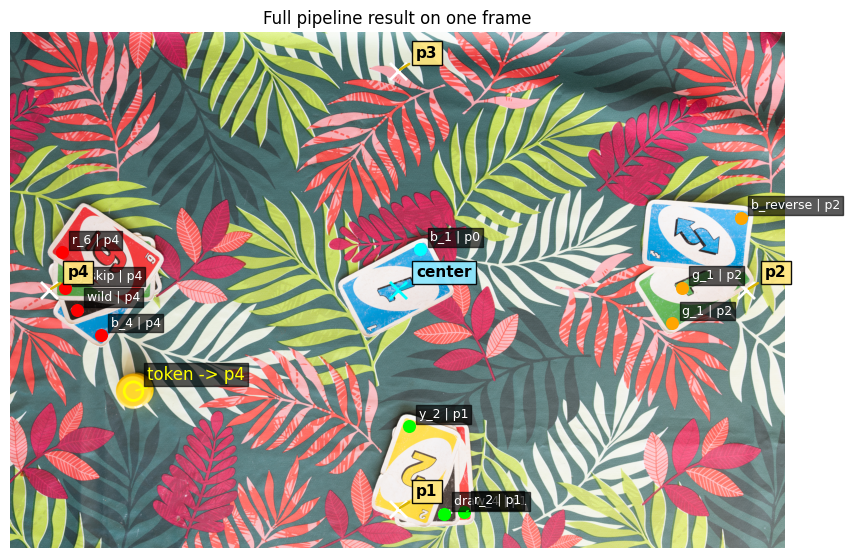

{'image_id': 'L1000993',
 'center_card': 'b_1',
 'active_player': 'p4',
 'player_1_cards': 'y_2;draw_4;r_2',
 'player_2_cards': 'b_reverse;g_1;g_1',
 'player_3_cards': 'EMPTY',
 'player_4_cards': 'r_6;g_skip;wild;b_4'}

In [30]:
full_debug = build_pipeline_debug(example_frame, classifier)
show_full_pipeline_frame(full_debug, remove_duplicates=True)
plt.show()
full_debug['row']


## Result Analysis

On the validation symbol dataset, the CNN reaches an accuracy and F1 score of `1.0`. This means that, on the prepared validation split of extracted and augmented symbol patches, every patch is classified correctly. The confusion matrix confirms this: the predictions stay on the diagonal, so no symbol class is systematically confused with another one. This perfect score should be interpreted as evidence that the classifier solves the clean patch-recognition subproblem, not as proof that the complete image pipeline is error-free.

On the full demo frame, the end-to-end pipeline detects the center card as `b_7` and assigns the active player to `p2`. The player hands are also reconstructed from the detected symbols and colors. The duplicate-removal step is important here: before correction, several physical cards appear more than once because both corner symbols can be detected separately. After removal, the player hands are cleaner and better match the expected card-level representation.

These results show that the CNN classification stage is reliable when segmentation provides a clean, centered binary patch. The remaining difficulty of the full pipeline mainly comes from earlier and later stages: detecting the correct symbol instances, associating them with the right card, removing duplicate corner detections, and assigning each card to the correct player.
